# 04 — Experimento 1: TF-IDF + Regresión Logística

Primer experimento de modelado: baseline léxico. Representamos cada minuta con TF-IDF
(unigramas + bigramas) y entrenamos una regresión logística multinomial. Es el piso de
rendimiento que los modelos más complejos (lexicón, Word2Vec, FinBERT) deben superar.

**Input:** `data/processed/fomc_dataset.csv`

**Outputs:** figuras en `reports/figures/` (`04_confusion_val.png`, `04_confusion_test.png`)

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

sns.set_theme(style='whitegrid', palette='Set2')
pd.options.display.max_colwidth = 200

# Rutas (mismas convenciones que notebooks 02/03)
BASE_DIR       = Path('..').resolve()
DATA_PROCESSED = BASE_DIR / 'data' / 'processed'
REPORTS_DIR    = BASE_DIR / 'reports' / 'figures'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

LABEL_ORDER = ['hike', 'cut', 'hold']

def save_fig(name):
    plt.savefig(REPORTS_DIR / name, dpi=120, bbox_inches='tight')

# Cargar dataset y particiones cronológicas (ya materializadas en la columna 'split')
df = pd.read_csv(DATA_PROCESSED / 'fomc_dataset.csv', parse_dates=['date'])
train = df[df.split == 'train']
val   = df[df.split == 'val']
test  = df[df.split == 'test']

print('train:', len(train), '| val:', len(val), '| test:', len(test))
print(pd.crosstab(df['label'], df['split']))

train: 145 | val: 32 | test: 32
split  test  train  val
label                  
cut       6     18    4
hike     11     25    4
hold     15    102   24


## Nota sobre el dataset y la evaluación

El corpus se extendió a **2000–2025** y las etiquetas se corrigieron: la decisión de cada reunión
se determina comparando la tasa **antes vs después de esa misma reunión** (no entre reuniones
consecutivas, que desfasaba la etiqueta una reunión). Dataset final: **209 documentos**, split
cronológico **train 2000–2017 (145), val 2018–2021 (32), test 2022–2025 (32)**, con las **tres
clases en los tres conjuntos**.

- La **comparación de modelos se hace sobre validación**; el **test (2022–2025)** es generalización
  out-of-sample sobre un período difícil (subas inflacionarias 2022–23 + recortes de normalización
  2024–25).
- Como los tres conjuntos tienen las tres clases, el F1-macro de val y test se promedia sobre 3
  clases y **sí es comparable** entre sí.
- val y test son chicos (32 docs c/u) → las métricas tienen algo de ruido.

In [2]:
# Helper de evaluación compartido por todos los experimentos.
# Reporta accuracy + F1-macro + classification_report (P/R/F1 por clase) + matriz de confusión.
#
# El F1-macro se promedia sobre las clases presentes en y_true (en el dataset extendido las tres
# clases están en train, val y test, así que val y test promedian sobre 3 clases y son comparables).
def evaluar(y_true, y_pred, titulo, fname=None):
    clases_presentes = [c for c in LABEL_ORDER if c in set(y_true)]
    f1 = f1_score(y_true, y_pred, labels=clases_presentes, average='macro')

    print(titulo)
    print('accuracy :', round(accuracy_score(y_true, y_pred), 4))
    print(f'f1_macro : {round(f1, 4)}  (promedio sobre {len(clases_presentes)} clases presentes: {clases_presentes})')
    print(classification_report(y_true, y_pred, labels=LABEL_ORDER, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=LABEL_ORDER)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER, ax=ax)
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real'); ax.set_title(titulo)
    if fname:
        save_fig(fname)
    plt.show()
    return f1

## 1. Baseline trivial (clase mayoritaria)

`DummyClassifier(strategy='prior')` predice siempre la clase mayoritaria de train (`hold`).
Es la cota inferior: cualquier modelo útil debe superar su F1-macro.

Baseline (majority) — VAL
accuracy : 0.75
f1_macro : 0.2857  (promedio sobre 3 clases presentes: ['hike', 'cut', 'hold'])
              precision    recall  f1-score   support

        hike       0.00      0.00      0.00         4
         cut       0.00      0.00      0.00         4
        hold       0.75      1.00      0.86        24

    accuracy                           0.75        32
   macro avg       0.25      0.33      0.29        32
weighted avg       0.56      0.75      0.64        32



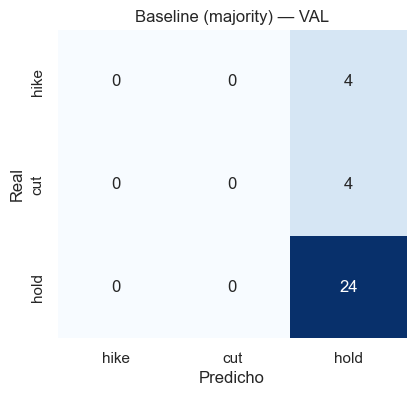

Baseline (majority) — TEST
accuracy : 0.4688
f1_macro : 0.2128  (promedio sobre 3 clases presentes: ['hike', 'cut', 'hold'])
              precision    recall  f1-score   support

        hike       0.00      0.00      0.00        11
         cut       0.00      0.00      0.00         6
        hold       0.47      1.00      0.64        15

    accuracy                           0.47        32
   macro avg       0.16      0.33      0.21        32
weighted avg       0.22      0.47      0.30        32



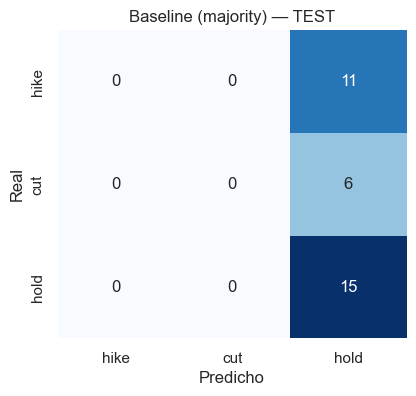

0.2127659574468085

In [3]:
dummy = DummyClassifier(strategy='prior')
dummy.fit(train['text'], train['label'])

evaluar(val['label'],  dummy.predict(val['text']),  'Baseline (majority) — VAL')
evaluar(test['label'], dummy.predict(test['text']), 'Baseline (majority) — TEST')

## 2. TF-IDF + Regresión Logística

Vectorizador ajustado **solo sobre train** (evita data leakage). Configuración del spec:
`ngram_range=(1,2)`, `max_features=10000`, `sublinear_tf=True`. La regresión logística usa
`class_weight='balanced'` por el desbalance de clases, y tuneamos `C` sobre validación.

In [4]:
# Ajustar TF-IDF solo en train; transformar las tres particiones
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=10000, sublinear_tf=True)
X_train = vectorizer.fit_transform(train['text'])
X_val   = vectorizer.transform(val['text'])
X_test  = vectorizer.transform(test['text'])
y_train, y_val, y_test = train['label'], val['label'], test['label']

print('Vocabulario TF-IDF:', len(vectorizer.vocabulary_))
print('X_train:', X_train.shape)

Vocabulario TF-IDF: 10000
X_train: (145, 10000)


In [5]:
# Grid search de C sobre validación (F1-macro)
C_grid = [0.01, 0.1, 1, 10]
resultados = []
for C in C_grid:
    clf = LogisticRegression(C=C, max_iter=1000, class_weight='balanced')
    clf.fit(X_train, y_train)
    f1_val = f1_score(y_val, clf.predict(X_val), average='macro')
    resultados.append((C, f1_val))
    print(f'C={C:<5} -> F1-macro val = {f1_val:.4f}')

best_C = max(resultados, key=lambda t: t[1])[0]
print(f'\nMejor C (por F1-macro en val): {best_C}')

C=0.01  -> F1-macro val = 0.2857
C=0.1   -> F1-macro val = 0.2857
C=1     -> F1-macro val = 0.4242
C=10    -> F1-macro val = 0.5185

Mejor C (por F1-macro en val): 10


TF-IDF + LogReg (C=10) — VAL
accuracy : 0.8125
f1_macro : 0.5185  (promedio sobre 3 clases presentes: ['hike', 'cut', 'hold'])
              precision    recall  f1-score   support

        hike       1.00      0.50      0.67         4
         cut       0.00      0.00      0.00         4
        hold       0.80      1.00      0.89        24

    accuracy                           0.81        32
   macro avg       0.60      0.50      0.52        32
weighted avg       0.73      0.81      0.75        32



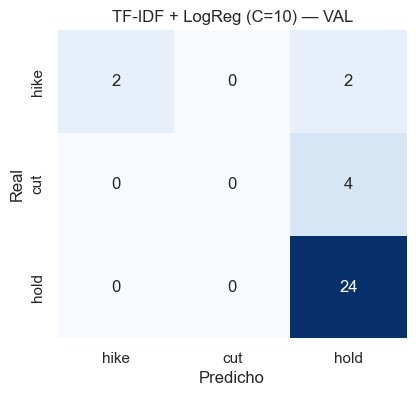

TF-IDF + LogReg (C=10) — TEST
accuracy : 0.4688
f1_macro : 0.2128  (promedio sobre 3 clases presentes: ['hike', 'cut', 'hold'])
              precision    recall  f1-score   support

        hike       0.00      0.00      0.00        11
         cut       0.00      0.00      0.00         6
        hold       0.47      1.00      0.64        15

    accuracy                           0.47        32
   macro avg       0.16      0.33      0.21        32
weighted avg       0.22      0.47      0.30        32



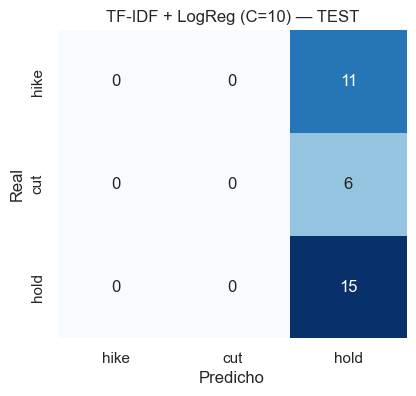

0.2127659574468085

In [6]:
# Reentrenar con el mejor C y evaluar en val y test
clf = LogisticRegression(C=best_C, max_iter=1000, class_weight='balanced')
clf.fit(X_train, y_train)

evaluar(y_val,  clf.predict(X_val),  f'TF-IDF + LogReg (C={best_C}) — VAL',  '04_confusion_val.png')
evaluar(y_test, clf.predict(X_test), f'TF-IDF + LogReg (C={best_C}) — TEST', '04_confusion_test.png')

## 3. Features más discriminativos por clase

Los coeficientes de la regresión logística (uno por clase, OvR multinomial) indican qué
n-gramas empujan cada decisión. Útil para interpretar y para la presentación.

In [7]:
feature_names = np.array(vectorizer.get_feature_names_out())
top_n = 15
for i, clase in enumerate(clf.classes_):
    top_idx = np.argsort(clf.coef_[i])[::-1][:top_n]
    print(f'\n[{clase}] top {top_n} features:')
    print(', '.join(feature_names[top_idx]))


[cut] top 15 features:
basis point, reducing funds, consistent reducing, point reduction, easing, economic weakness, easing action, easing policy, policy easing, meyer minehan, weakness foreseeable, hoenig kelley, reduction funds, easing actions, softening

[hike] top 15 features:
prospects needed, respond changes, consistent increasing, increasing funds, likely measured, removed pace, percent effective, changes economic, growth price, maintain price, fulfill, fulfill obligation, needed fulfill, obligation maintain, removed

[hold] top 15 features:
consistent maintaining, maintaining funds, economic recovery, unchanged policy, maintaining, predominant, tone, july, policy stance, june, leave target, sloos, fail, sales motor, inventory investment


## 4. Interpretación

- **TF-IDF + LogReg (C=10) supera al baseline en validación:** F1-macro **0.519 vs 0.286**,
  accuracy 0.812. La regularización importa: con C bajo (0.01–0.1) colapsa a `hold` (0.286 =
  baseline), pero con C=10 aprende a separar. Matriz de confusión val:
  ```
          hike  cut  hold
  hike  [  2    0    2 ]   detecta 2 de 4 hikes
  cut   [  0    0    4 ]   no detecta ningún cut
  hold  [  0    0   24 ]   24 de 24 hold
  ```
  Detecta subas y holds, pero **ningún `cut`**.
- **Overfitting fuerte:** en train la accuracy es **1.0** (memoriza perfecto). Con 145 documentos
  y 10 000 features el modelo aprende el train de memoria; lo que generaliza es poco.
- **En test colapsa a `hold`:** predice `hold` a los 32 documentos → F1-macro **0.213 = baseline**.
  No generaliza al período 2022–2025 (vocabulario nuevo: inflación, balance-sheet runoff, etc.).
- **Coeficientes interpretables y coherentes con el dominio:**
  - `cut` → `easing`, `point reduction`, `basis point`, `policy easing`, `economic weakness`.
  - `hike` → `increasing funds`, `measured pace`, `maintain price`, `removed`.
  - `hold` → `maintaining funds`, `unchanged policy`, `economic recovery`, `policy stance`.

**Conclusión del experimento:** con etiquetas correctas y un poco más de regularización, TF-IDF
**sí supera al baseline en validación** (reconoce vocabulario de subas que se repite entre ciclos),
pero memoriza el train (acc 1.0) y **colapsa a `hold` en test**, sin generalizar al período
2022–2025. La coincidencia léxica exacta no transfiere a través del drift. Esto motiva
representaciones que capturen tono de dominio (lexicón LM, Exp 2) y semántica/contexto (Word2Vec y
FinBERT, Exp 3 y 4).